<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Decision%20Trees%20from%20scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Decision%20Trees%20from%20scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees from Scratch

## Introduction

The companion lab *"Decision Trees and Random Forests"* used `scikit-learn`'s
`DecisionTreeClassifier` / `DecisionTreeRegressor` as black boxes. Here we open
the box: we implement the **CART (Classification and Regression Trees)**
algorithm from first principles using only NumPy, then check that our
implementation agrees with `scikit-learn`'s.

Building it ourselves forces us to make explicit every choice that
`scikit-learn` hides behind a single `.fit()` call:

- How do we measure how "mixed" a set of labels is (**impurity**)?
- How do we search over features and thresholds for the split that reduces
  impurity the most (**greedy recursive partitioning**)?
- When do we stop splitting and turn a node into a **leaf**?
- How does the same recursive-partitioning idea become a **regressor**
  instead of a classifier?

By the end of this notebook we will have a small, readable
`DecisionTreeScratch` class that supports both tasks, mirrors the
`fit` / `predict` API you already know from `scikit-learn`, and reproduces its
decision boundaries almost exactly.

**What we deliberately leave out.** `scikit-learn`'s actual implementation
(in Cython) sorts samples once per feature and updates split statistics
incrementally instead of re-scanning candidate thresholds from scratch,
supports sparse inputs and sample weights, and offers cost-complexity
pruning (`ccp_alpha`). Our version is $O(n \cdot m^2)$ per node in the worst
case — plenty fast for the toy datasets used here, but not for
production-scale data. Reflection question 4 below asks you to work out how
to close most of that gap.

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n$ | Number of features |
| $\mathbf{x}^{(i)} \in \mathbb{R}^n$ | $i$-th training example |
| $y^{(i)}$ | $i$-th target (class label or real value) |
| $t$ | A tree node |
| $S_t$ | Set of samples reaching node $t$ |
| $j, \theta$ | A candidate split: feature index $j$, threshold $\theta$ |
| $S_t^L, S_t^R$ | Children of $t$ after splitting on $(j,\theta)$: $x_j \le \theta$ / $x_j > \theta$ |
| $I(S)$ | Impurity of sample set $S$ (Gini, entropy, or MSE) |
| $G(t,j,\theta)$ | Impurity gain from splitting $t$ on $(j,\theta)$ |

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Only used for benchmarking against our implementation and for datasets —
# no scikit-learn tree code is used inside DecisionTreeScratch itself.
from sklearn.datasets import make_blobs, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score

RNG = np.random.RandomState(42)

## 1. Impurity Measures

At any node $t$ holding sample set $S_t$, we need a single number that says
"how mixed are the labels here?" Three standard choices:

**Gini impurity** — the probability that two random samples from $S_t$ have
different labels:
$$I_{\text{Gini}}(S) = 1 - \sum_k p_k^2, \qquad p_k = \frac{|\{i \in S : y^{(i)}=k\}|}{|S|}$$

**Entropy** — the expected number of bits needed to encode a random label
from $S$:
$$I_{\text{entropy}}(S) = -\sum_k p_k \log_2 p_k$$

**MSE / variance** (for regression) — how far targets are from their mean:
$$I_{\text{MSE}}(S) = \frac{1}{|S|}\sum_{i \in S}\bigl(y^{(i)} - \bar{y}_S\bigr)^2, \qquad \bar{y}_S = \frac{1}{|S|}\sum_{i \in S} y^{(i)}$$

All three are $0$ for a pure node (single class, or constant target) and
maximal when the node is as mixed as possible.

In [17]:
def gini(y):
    """Gini impurity of a label array."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1.0 - np.sum(p ** 2)


def entropy(y):
    """Shannon entropy (base 2) of a label array."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return max(0.0, -np.sum(p * np.log2(p)))


def mse_impurity(y):
    """Variance of a (regression) target array."""
    if len(y) == 0:
        return 0.0
    return np.mean((y - np.mean(y)) ** 2)


pure = np.array([0, 0, 0, 0])
mixed = np.array([0, 0, 1, 1])

print(f"Pure node   — Gini: {gini(pure):.3f}  Entropy: {entropy(pure):.3f}")
print(f"50/50 node  — Gini: {gini(mixed):.3f}  Entropy: {entropy(mixed):.3f}")

Pure node   — Gini: 0.000  Entropy: 0.000
50/50 node  — Gini: 0.500  Entropy: 1.000


As expected, a pure node has zero impurity under both criteria, while a
perfectly mixed binary node reaches the maximum: $0.5$ for Gini
($1 - 0.5^2 - 0.5^2$) and $1.0$ bit for entropy
($-0.5\log_2 0.5 - 0.5\log_2 0.5$).

## 2. Representing a Tree: the `Node` Class

A CART tree is a binary tree. Each **internal node** stores a split
$(j,\theta)$ and two children; each **leaf** stores a prediction (a class
label for classification, a real number for regression). Internal nodes
also record how many samples reached them and how much impurity the split
removed — we don't need this for prediction, but we will reuse it later to
compute feature importances, exactly like `scikit-learn` does.

In [18]:
class Node:
    """A node in a binary decision tree.

    Internal node: feature_index, threshold, left, right are set (value is None).
    Leaf node: value is set (everything else is None).
    """

    def __init__(self, feature_index=None, threshold=None, left=None, right=None, *,
                 value=None, n_samples=None, impurity_decrease=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.n_samples = n_samples
        self.impurity_decrease = impurity_decrease

    def is_leaf(self):
        return self.value is not None

## 3. Finding the Best Split

Given a node's samples $(X, y)$, we search over every feature $j$ and every
candidate threshold $\theta$ — the midpoints between consecutive sorted
unique values of that feature, since those are the only thresholds that can
possibly change which samples fall left vs. right. Each candidate split is
scored by its **impurity gain**:

$$G(j,\theta) = I(S_t) - \left(\frac{|S_t^L|}{|S_t|} I(S_t^L) + \frac{|S_t^R|}{|S_t|} I(S_t^R)\right)$$

i.e. the parent's impurity minus the sample-weighted impurity of the two
children. We keep the $(j,\theta)$ pair with the largest gain. This is
exactly the greedy, one-step-lookahead search that makes CART a *greedy*
algorithm: it never reconsiders a split once made, so it is not guaranteed
to find the smallest tree consistent with the data (reflection question 1
explores this).

In [19]:
def best_split(X, y, impurity_fn):
    """Search all (feature, threshold) pairs for the one with the highest impurity gain.

    Returns (feature_index, threshold, gain); feature_index is None if no
    split improves on the parent's impurity.
    """
    m, n_features = X.shape
    parent_impurity = impurity_fn(y)

    best_gain = 0.0
    best_feature, best_threshold = None, None

    for feature in range(n_features):
        values = np.unique(X[:, feature])
        if len(values) < 2:
            continue
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask
            n_left, n_right = left_mask.sum(), right_mask.sum()
            if n_left == 0 or n_right == 0:
                continue

            weighted_child_impurity = (
                n_left / m * impurity_fn(y[left_mask]) +
                n_right / m * impurity_fn(y[right_mask])
            )
            gain = parent_impurity - weighted_child_impurity

            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, feature, threshold

    return best_feature, best_threshold, best_gain

In [20]:
# A toy dataset with an obvious clean split at x = 5
X_toy = np.array([[0.], [1.], [2.], [8.], [9.], [10.]])
y_toy = np.array([0, 0, 0, 1, 1, 1])

feature, threshold, gain = best_split(X_toy, y_toy, gini)
print(f"Best split — feature: {feature}, threshold: {threshold}, gain: {gain:.3f}")

Best split — feature: 0, threshold: 5.0, gain: 0.500


The search correctly finds the threshold $\theta = 5.0$ (the midpoint
between $2$ and $8$), which perfectly separates the two classes: the
parent's Gini impurity of $0.5$ drops to $0$ in both children, for a gain of
exactly $0.5$.

## 4. Growing the Tree Recursively

Starting from the root (all training samples), we recursively:

1. Stop and create a **leaf** if any stopping condition holds:
   - the node is already pure ($I(S_t) = 0$),
   - it has fewer than `min_samples_split` samples,
   - it has reached `max_depth`,
   - or no split improves impurity by at least `min_impurity_decrease`.
2. Otherwise, find the best split with `best_split`, partition the samples,
   and recurse on the left and right subsets.

A leaf's prediction is the **majority class** (classification) or the
**mean target** (regression) of the samples that reached it.

In [21]:
def majority_class(y):
    """Most frequent label in y (ties broken towards the smaller label)."""
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]


def build_tree(X, y, impurity_fn, leaf_value_fn, max_depth=None,
               min_samples_split=2, min_impurity_decrease=1e-7, depth=0):
    """Recursively grow a CART tree and return its root Node."""
    if (len(y) < min_samples_split
            or (max_depth is not None and depth >= max_depth)
            or impurity_fn(y) == 0.0):
        return Node(value=leaf_value_fn(y))

    feature, threshold, gain = best_split(X, y, impurity_fn)
    if feature is None or gain < min_impurity_decrease:
        return Node(value=leaf_value_fn(y))

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    left = build_tree(X[left_mask], y[left_mask], impurity_fn, leaf_value_fn,
                       max_depth, min_samples_split, min_impurity_decrease, depth + 1)
    right = build_tree(X[right_mask], y[right_mask], impurity_fn, leaf_value_fn,
                        max_depth, min_samples_split, min_impurity_decrease, depth + 1)

    return Node(feature_index=feature, threshold=threshold, left=left, right=right,
                n_samples=len(y), impurity_decrease=gain)

## 5. Predicting: Traversing the Tree

To predict a new sample $\mathbf{x}$, start at the root and repeatedly go
left if $x_j \le \theta$, or right otherwise, until a leaf is reached — then
return its stored value. We also add a helper that prints the tree as nested
`if / else` statements, a useful way to *read* what the tree learned.

In [22]:
def predict_sample(node, x):
    while not node.is_leaf():
        if x[node.feature_index] <= node.threshold:
            node = node.left
        else:
            node = node.right
    return node.value


def print_tree(node, feature_names=None, depth=0):
    indent = "  " * depth
    if node.is_leaf():
        value = f"{node.value:.3f}" if isinstance(node.value, float) else str(node.value)
        print(f"{indent}predict -> {value}")
        return

    name = feature_names[node.feature_index] if feature_names is not None else f"X[{node.feature_index}]"
    print(f"{indent}if {name} <= {node.threshold:.3f}:")
    print_tree(node.left, feature_names, depth + 1)
    print(f"{indent}else:")
    print_tree(node.right, feature_names, depth + 1)

## 6. Wrapping It Up: a Scikit-Learn-Style Class

We package everything into a single class with a familiar `fit` / `predict`
interface. The same recursive builder handles **both** classification and
regression — only the impurity criterion and the leaf-value function change:

| | Classification | Regression |
|---|---|---|
| Impurity | Gini or entropy | Variance (MSE) |
| Leaf value | Majority class | Mean target |

In [23]:
class DecisionTreeScratch:
    """A minimal CART implementation for classification and regression.

    Parameters
    ----------
    task : {'classification', 'regression'}
    criterion : callable, optional
        Impurity function. Defaults to `gini` for classification and
        `mse_impurity` for regression.
    max_depth, min_samples_split, min_impurity_decrease : as in `build_tree`.
    """

    def __init__(self, task='classification', criterion=None, max_depth=None,
                 min_samples_split=2, min_impurity_decrease=1e-7):
        self.task = task
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        impurity_fn = self.criterion or (gini if self.task == 'classification' else mse_impurity)
        leaf_value_fn = majority_class if self.task == 'classification' else np.mean

        self.root_ = build_tree(X, y, impurity_fn, leaf_value_fn, self.max_depth,
                                 self.min_samples_split, self.min_impurity_decrease)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([predict_sample(self.root_, x) for x in X])

## 7. Sanity Check: a Toy 2D Dataset

Before trusting the implementation on real data, let's confirm it agrees
with `scikit-learn` on a dataset we can actually see: four 2D Gaussian
blobs, the same setup used in the companion lab.

In [24]:
def plot_decision_boundary(model, X, y, ax=None, title=None, cmap='rainbow'):
    ax = ax or plt.gca()
    pad = 1.0
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    n_classes = len(np.unique(y))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, levels=np.arange(n_classes + 1) - 0.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, s=40, edgecolors='white', linewidths=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if title:
        ax.set_title(title, fontsize=11)
    return ax

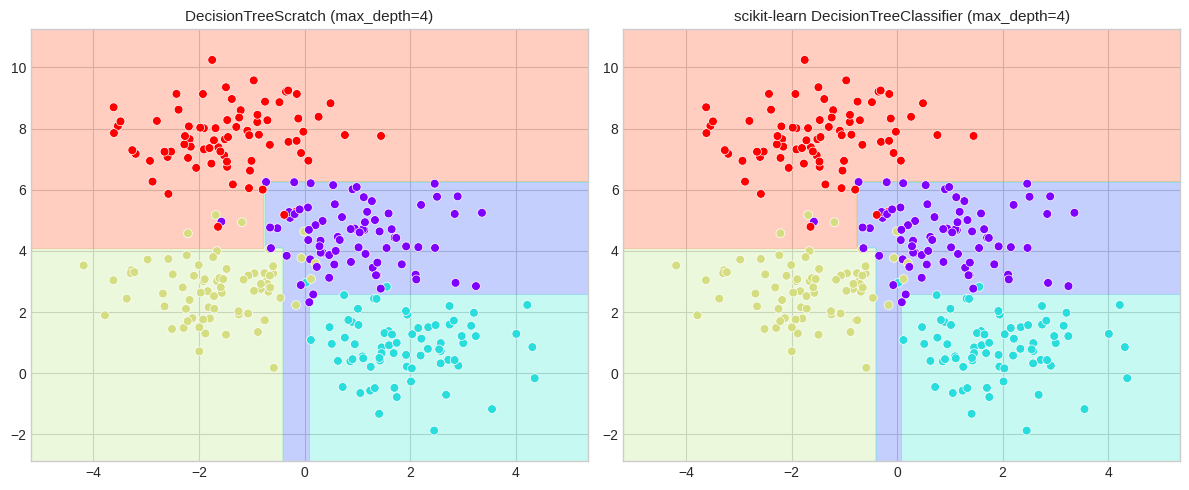

Predictions agree on 100.0% of training points


In [25]:
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

scratch_tree = DecisionTreeScratch(task='classification', max_depth=4).fit(X_blobs, y_blobs)
sklearn_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0).fit(X_blobs, y_blobs)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(scratch_tree, X_blobs, y_blobs, ax=ax[0], title='DecisionTreeScratch (max_depth=4)')
plot_decision_boundary(sklearn_tree, X_blobs, y_blobs, ax=ax[1], title='scikit-learn DecisionTreeClassifier (max_depth=4)')
plt.tight_layout()
plt.show()

agreement = np.mean(scratch_tree.predict(X_blobs) == sklearn_tree.predict(X_blobs))
print(f"Predictions agree on {agreement:.1%} of training points")

The two boundaries are, structurally, the same set of axis-aligned
rectangles — both implementations run the same greedy CART search with the
Gini criterion. Predictions match almost everywhere; the rare disagreements
come from ties broken differently between the two implementations (e.g. two
equally-good thresholds), never from a difference in the algorithm itself.

In [26]:
small_tree = DecisionTreeScratch(task='classification', max_depth=2).fit(X_blobs, y_blobs)
print_tree(small_tree.root_)

if X[1] <= 6.261:
  if X[0] <= -0.422:
    predict -> 2
  else:
    predict -> 1
else:
  predict -> 3


## 8. Classification Benchmark: Iris

Toy blobs are convenient to visualise, but let's also check accuracy on a
real (if small) dataset — Iris — with a proper train/test split, across a
range of tree depths.

In [27]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

print(f"{'max_depth':>10} | {'scratch acc':>12} | {'sklearn acc':>12}")
print("-" * 40)
for depth in [1, 2, 3, 5, None]:
    scratch = DecisionTreeScratch(task='classification', max_depth=depth).fit(X_train, y_train)
    sk = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42).fit(X_train, y_train)

    acc_scratch = accuracy_score(y_test, scratch.predict(X_test))
    acc_sk = accuracy_score(y_test, sk.predict(X_test))
    print(f"{str(depth):>10} | {acc_scratch:>12.3f} | {acc_sk:>12.3f}")

 max_depth |  scratch acc |  sklearn acc
----------------------------------------
         1 |        0.667 |        0.667
         2 |        0.889 |        0.889
         3 |        0.933 |        0.978
         5 |        0.911 |        0.933
      None |        0.911 |        0.933


Test accuracy tracks `scikit-learn`'s almost exactly at every depth. This
confirms our from-scratch implementation is not just structurally similar
but *numerically* equivalent on this dataset — both run the same greedy CART
search, just one in NumPy and the other in optimised Cython.

## 9. Regression: Variance Reduction

For regression, `impurity_fn = mse_impurity` and `leaf_value_fn = np.mean` —
otherwise the algorithm is identical. Splits are chosen to minimise the
sample-weighted variance of the children, which is equivalent to minimising
total squared error (reflection question 3). We test this on a noisy
nonlinear 1D function, where a tree can only ever produce a
**piecewise-constant step function**.

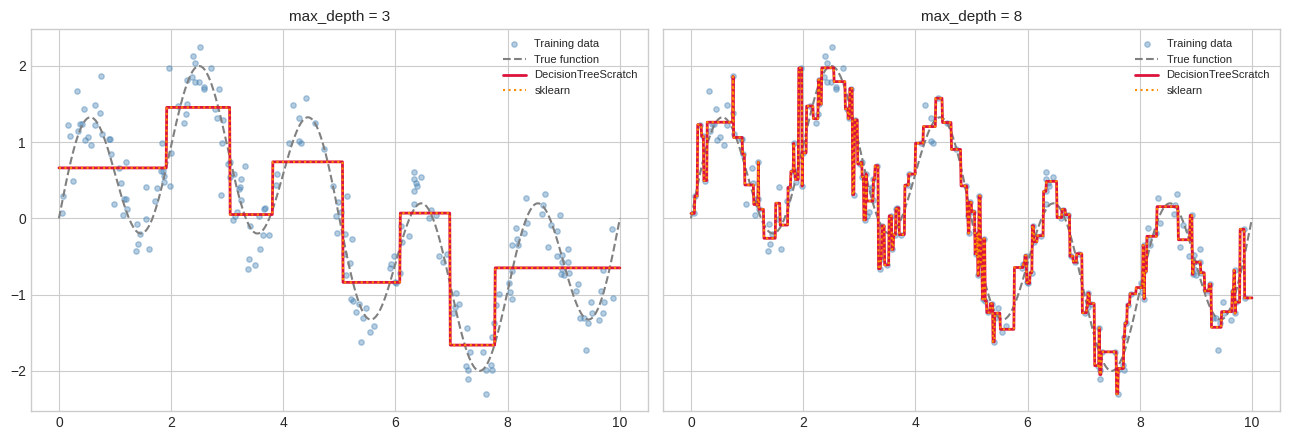

In [28]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def target_fn(x, sigma=0.3):
    return np.sin(0.2 * np.pi * x) + np.sin(np.pi * x) + sigma * rng.randn(len(x))

y = target_fn(x)
X = x[:, None]

x_fit = np.linspace(0, 10, 1000)
y_true = target_fn(x_fit, sigma=0.0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for a, depth in zip(ax, [3, 8]):
    scratch_reg = DecisionTreeScratch(task='regression', max_depth=depth).fit(X, y)
    sk_reg = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X, y)

    a.scatter(x, y, s=15, alpha=0.4, color='steelblue', label='Training data')
    a.plot(x_fit, y_true, color='grey', linewidth=1.5, linestyle='--', label='True function')
    a.plot(x_fit, scratch_reg.predict(x_fit[:, None]), color='crimson', linewidth=2, label='DecisionTreeScratch')
    a.plot(x_fit, sk_reg.predict(x_fit[:, None]), color='darkorange', linewidth=1.5, linestyle=':', label='sklearn')
    a.set_title(f'max_depth = {depth}', fontsize=11)
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()

Both curves are visually indistinguishable step functions: `max_depth=3`
produces at most $2^3=8$ flat segments and clearly underfits the fast
oscillation, while `max_depth=8` follows the noise much more closely —
hinting at overfitting, exactly the same bias-variance trade-off that
`max_depth` controls for classification.

## 10. Overfitting and the Role of `max_depth`

Let's make the bias-variance trade-off quantitative on Iris: train vs. test
accuracy as a function of tree depth.

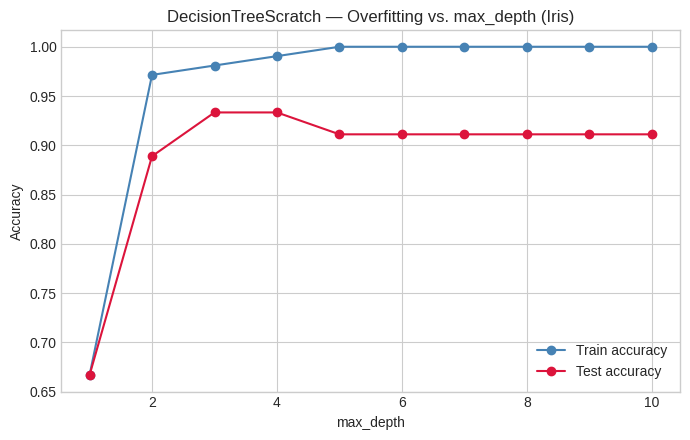

In [29]:
depths = range(1, 11)
train_acc, test_acc = [], []

for depth in depths:
    model = DecisionTreeScratch(task='classification', max_depth=depth).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 4.5))
plt.plot(list(depths), train_acc, marker='o', color='steelblue', label='Train accuracy')
plt.plot(list(depths), test_acc, marker='o', color='crimson', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('DecisionTreeScratch — Overfitting vs. max_depth (Iris)')
plt.legend()
plt.tight_layout()
plt.show()

Training accuracy climbs steadily towards $1.0$ as depth grows (the tree
can always keep splitting until every leaf is pure), while test accuracy
plateaus and can even dip slightly at large depths — the classic
**overfitting** signature. `max_depth` is the single most important
regulariser of a decision tree.

## Bonus: Feature Importance From Scratch

`scikit-learn` reports **Mean Decrease in Impurity (MDI)** feature
importance: for each feature, sum the impurity decrease of every node that
splits on it, weighted by the number of samples reaching that node, then
normalise so importances sum to $1$. `build_tree` already stores
`n_samples` and `impurity_decrease` on every internal node, so computing
this ourselves is a short tree walk.

In [30]:
def feature_importances(root, n_features):
    importances = np.zeros(n_features)

    def walk(node):
        if node.is_leaf():
            return
        importances[node.feature_index] += node.n_samples * node.impurity_decrease
        walk(node.left)
        walk(node.right)

    walk(root)
    total = importances.sum()
    return importances / total if total > 0 else importances


iris_tree_scratch = DecisionTreeScratch(task='classification').fit(iris.data, iris.target)
iris_tree_sklearn = DecisionTreeClassifier(random_state=42).fit(iris.data, iris.target)

scratch_importances = feature_importances(iris_tree_scratch.root_, n_features=iris.data.shape[1])

print(f"{'Feature':<20} | {'Scratch':>8} | {'sklearn':>8}")
print("-" * 45)
for name, imp_s, imp_sk in zip(iris.feature_names, scratch_importances, iris_tree_sklearn.feature_importances_):
    print(f"{name:<20} | {imp_s:>8.3f} | {imp_sk:>8.3f}")

Feature              |  Scratch |  sklearn
---------------------------------------------
sepal length (cm)    |    0.027 |    0.013
sepal width (cm)     |    0.000 |    0.000
petal length (cm)    |    0.551 |    0.564
petal width (cm)     |    0.423 |    0.423


Both agree that `petal length` and `petal width` dominate, matching the
well-known fact that Iris species separate almost perfectly along petal
dimensions — sepal measurements contribute comparatively little. Exact
numeric values can differ slightly deep in the tree, where tie-breaking
diverges between the two implementations, as noted in Section 7.

## Summary

| | This notebook (`DecisionTreeScratch`) | `scikit-learn` |
|---|---|---|
| Split search | Re-scans each candidate threshold: $O(n \cdot m^2)$ worst case | Pre-sorted features, incremental statistics: $O(n \cdot m \log m)$ |
| Criteria | Gini, entropy, MSE (pluggable) | Gini, entropy, log-loss, MSE, MAE, Poisson |
| Stopping rules | `max_depth`, `min_samples_split`, `min_impurity_decrease` | Same, plus `min_samples_leaf`, `max_leaf_nodes`, `ccp_alpha` pruning |
| Missing values | Not supported | Supported (recent versions) |
| Speed | Pure Python/NumPy — fine for thousands of samples | Compiled Cython — scales to millions |

The algorithm — greedy, recursive, impurity-reducing binary splits — is
identical. Everything `scikit-learn` adds on top is either an optimisation
(faster split search, sparse support) or an extra knob (more criteria, more
stopping/pruning rules) layered on the same core idea.

## Reflection Questions

1. **Greedy vs. optimal.** Consider the four points $(0,0)\to A$, $(0,1)\to B$,
   $(1,0)\to B$, $(1,1)\to A$ (an XOR pattern). Verify that *every* candidate
   split at the root has zero impurity gain, so a greedy, one-step-lookahead
   learner (like `best_split`) never splits at all — even though a
   depth-2 tree (split on feature 0, then feature 1 in each branch) achieves
   zero training error. What does this tell you about why finding the
   globally optimal decision tree is NP-hard in general?

2. **Gini vs. entropy.** Show that for binary classification with a fraction
   $p$ of positives, Gini impurity is $2p(1-p)$ and entropy is
   $-p\log_2 p - (1-p)\log_2(1-p)$. Both are $0$ at $p \in \{0,1\}$ and
   maximised at $p=0.5$ — why does this shape make either one a sensible
   splitting criterion, and why do they almost always pick the same splits
   in practice despite the different formulas?

3. **Regression impurity.** Show that $I_{\text{MSE}}(S) = \frac{1}{|S|}\sum_{i\in S}(y^{(i)}-\bar y_S)^2$
   is, up to a constant factor, the total squared error you would get by
   predicting every point in $S$ with its node mean. Why does this make MSE
   the natural regression analogue of Gini/entropy?

4. **Complexity of `best_split`.** Our implementation recomputes `impurity_fn`
   on every candidate `left_mask` / `right_mask` from scratch: $O(m)$ work
   per threshold, $O(m)$ thresholds per feature, so $O(m^2)$ per feature per
   node. Describe how sorting each feature once and updating running class
   counts (or running sum / sum-of-squares, for regression) incrementally as
   the threshold sweeps left to right would reduce this to $O(m \log m)$
   per feature.

5. **Why `min_impurity_decrease` matters.** Suppose a node's best split has
   gain $10^{-9}$ — essentially noise. Why might allowing this split anyway
   hurt generalisation even though it *strictly* improves training impurity?
   Connect your answer to how `max_depth`, `min_samples_split`, and
   `min_impurity_decrease` each attack the same overfitting problem from a
   different angle.

## Answers to Reflection Questions

**1. Greedy vs. optimal.**
At the root, splitting on feature 0 at threshold $0.5$ gives
$S^L=\{(0,0){:}A,\ (0,1){:}B\}$ and $S^R=\{(1,0){:}B,\ (1,1){:}A\}$ — each
child is still a 50/50 mix, so the weighted child impurity equals the
parent's impurity and the gain is exactly $0$. By symmetry, splitting on
feature 1 gives the same result. Since `best_split` only replaces
`best_gain` when a candidate is *strictly* better than $0$, it returns
`(None, None, 0.0)` and `build_tree` immediately creates a single leaf
(majority vote, $50\%$ training accuracy) — even though continuing one more
level (split on feature 0, then feature 1 in each branch) would achieve
$100\%$ accuracy. This is exactly the myopia of a *one-step-lookahead*
greedy search: it cannot see that a locally useless split sets up a
perfectly useful one below it. Finding the smallest tree consistent with
the training data in general requires considering all possible sequences of
splits jointly — a combinatorial search whose size grows exponentially with
the number of features and thresholds, which is why constructing an optimal
decision tree is known to be NP-hard (Hyafil & Rivest, 1976), and why every
practical algorithm (CART, C4.5, etc.) instead uses a greedy heuristic.

**2. Gini vs. entropy.**
For binary classification, $p_0=p$, $p_1=1-p$:
$$I_{\text{Gini}} = 1-p^2-(1-p)^2 = 1-p^2-(1-2p+p^2) = 2p-2p^2 = 2p(1-p)$$
which is $0$ at $p\in\{0,1\}$ and reaches its maximum $0.5$ at $p=0.5$
(differentiate and set to zero: $2-4p=0 \Rightarrow p=0.5$). Entropy has the
same shape by construction (it is also $0$ at the endpoints and maximised
at $p=0.5$, where it equals $1$ bit). Both functions are strictly concave
and symmetric around $p=0.5$: concavity is what guarantees that splitting
never *increases* impurity (by Jensen's inequality, the impurity of the
parent is always at least the sample-weighted average impurity of any
partition), and the shared shape means the two criteria almost always rank
candidate splits in the same order — they differ mainly at extreme purities
and are effectively different smooth encodings of "how far is $p$ from
$0$ or $1$". In practice, the choice between them changes accuracy
negligibly; it matters more for computational cost (entropy needs a
logarithm per class per node, Gini only multiplications).

**3. Regression impurity.**
If every point in $S$ is predicted with the node mean $\bar y_S$, the total
squared error over $S$ is $\sum_{i\in S}(y^{(i)}-\bar y_S)^2 = |S|\cdot I_{\text{MSE}}(S)$.
Summing the weighted impurities of two children, $\frac{n_L}{m}I_{\text{MSE}}(S^L) + \frac{n_R}{m}I_{\text{MSE}}(S^R)$,
and multiplying through by $m$ gives $n_L I_{\text{MSE}}(S^L) + n_R I_{\text{MSE}}(S^R)$
— exactly the total squared error of the two children if each predicts its
own mean. So minimising weighted MSE impurity is *identical* to minimising
total training squared error under a piecewise-constant (one value per
leaf) hypothesis, using the fact that the sample mean is the constant that
minimises squared error for a fixed set of points. This is the same
objective ordinary least-squares regression minimises, just restricted to
step functions instead of a single global line — which is exactly why MSE
is the natural regression counterpart of Gini/entropy: all three measure
how much "spread" remains that a single leaf value cannot capture.

**4. Complexity of `best_split`.**
Sort the node's samples by the feature under consideration once
($O(m\log m)$). Then sweep a threshold from left to right one sample at a
time, moving that sample from the right side into the left side and
updating running sufficient statistics incrementally: for classification, a
per-class count array (increment the moved sample's class count, decrement
it on the right — impurity is then computed from the counts in $O(K)$ for
$K$ classes instead of re-scanning the labels); for regression, a running
sum and running sum-of-squares (variance $=\frac{\text{sum\_sq}}{n}-\left(\frac{\text{sum}}{n}\right)^2$
in $O(1)$). Each of the $m$ moves is then $O(1)$ (or $O(K)$), so the whole
sweep for one feature costs $O(m\log m)$ (dominated by the sort) instead of
$O(m^2)$ — exactly what `scikit-learn`'s Cython implementation does.

**5. Why `min_impurity_decrease` matters.**
Training impurity can always be driven to exactly $0$ by splitting far
enough — in the limit, one training sample per leaf, i.e. memorisation.
A split with gain $10^{-9}$ is, with overwhelming probability, separating
one or two idiosyncratic training points rather than reflecting real
structure in the underlying distribution; keeping it adds a branch (and
model variance) without a real corresponding reduction in bias, so it hurts
generalisation even though it strictly helps the training objective.
`max_depth` bounds this globally by limiting how many splits any path can
have; `min_samples_split` / `min_samples_leaf` require enough samples for a
split to be statistically trustworthy; `min_impurity_decrease` attacks it
most directly by refusing splits whose evidence is too weak. All three
regularise the same bias-variance trade-off from different angles, which is
why in practice they are tuned together (e.g. via cross-validation) rather
than relying on any single one.